# Tarea para el Hogar 04 — versión Python

Conversión de `z494_TareaHogar_04.ipynb`. La carga del dataset y la generación de la clase ternaria se reutilizan de `z0333_python.ipynb`.

# Librerías

In [1]:
import os
import cudf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import optuna
from optuna.samplers import GPSampler
from optuna.trial import TrialState
from optuna.visualization import plot_param_importances, plot_contour,  plot_slice, plot_optimization_history




print('cuDF:', cudf.__version__)
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())


cuDF: 26.08.01
GPU: NVIDIA GeForce RTX 3090


In [2]:
import lightgbm as lgb
import yaml

from scipy.spatial.distance import pdist
from scipy.stats import qmc

Dependencias adicionales respecto del notebook 0333: `lightgbm`, `scipy` y `pyyaml`.

# URLs

In [3]:
BASE_URL = os.path.join(
    os.path.expanduser("~"),
    "code", "DMEyF", "dmeyf2026"
)

DATA_URL = os.path.join(BASE_URL, "DATA")
DATASETS_URL = os.path.join(DATA_URL, "DATASETS")
EXP_URL = os.path.join(DATA_URL, "EXP")
dataset_url = os.path.join(DATASETS_URL,'competencia_01_crudo.csv')

experiment_name = "PY4945"
EXPERIMENT_URL = os.path.join(EXP_URL, experiment_name)

os.makedirs(EXPERIMENT_URL, exist_ok=True)

# Constantes

In [4]:
SEED = 230047

In [ ]:
PARAM = {
    "experimento": 4941,
    "semilla_primigenia": SEED,
    "train": [202104],
    "train_final": [202104],
    "future": [202106],
    "semilla_kaggle": 314159,
    "cortes": list(range(4_000, 19_001, 500)),
    "trainingstrategy": {"undersampling": 0.1},
    "hyperparametertuning": {
        "xval_folds": 5,
        "puntos_iniciales": 40,
        "iteraciones": 60,
    },
    "lgbm": {
        "param_fijos": {
            "boosting": "gbdt",
            "objective": "binary",
            # "metric": "auc",
            "metric": "average_precision",
            "first_metric_only": False,
            "boost_from_average": True,
            "feature_pre_filter": False,
            "force_row_wise": True,
            "verbosity": -100,
            "seed": SEED,
            "max_depth": -1,
            "min_gain_to_split": 0.0,
            "min_sum_hessian_in_leaf": 0.001,
            "lambda_l1": 0.0,
            "lambda_l2": 0.0,
            "max_bin": 31,
            "bagging_fraction": 1.0,
            "pos_bagging_fraction": 1.0,
            "neg_bagging_fraction": 1.0,
            "is_unbalance": False,
            "scale_pos_weight": 1.0,
            "drop_rate": 0.1,
            "max_drop": 50,
            "skip_drop": 0.5,
            "extra_trees": False,
            "num_iterations": 1200,
            "learning_rate": 0.002,
            "feature_fraction": 0.5,
            "num_leaves": 750,
            "min_data_in_leaf": 0,
        }
    },
    "out": {"lgbm": {}},
}

ESPACIO_BO = {
    "num_iterations": ("int", 200, 2500),
    "learning_rate": ("float", 0.001, 0.01),
    "feature_fraction": ("float", 0.3, 0.8),
    "num_leaves": ("int", 10, 2048),
    # "min_data_in_leaf": ("int", 0, 2000),
    "min_sum_hessian_in_leaf": ("float", 0.0001, 0.01),
}

# Lectura del dataset

In [6]:
# cudf no pandas -> GPU
df = cudf.read_csv(
    dataset_url,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [7]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares,Visa_fultimo_cierre,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,0.0,1,0.0,-16247.77,0.0,4056,15732.34,1,0,1137.81
1,12159858,202103,1,0,0,48,102,78.43,24418.75,-73.62,...,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN
2,12160484,202103,1,0,0,60,55,8101.55,3162.23,13399.50,...,0.0,1,0.0,-31103.23,0.0,1632,2860.54,2,0,19858.89
3,12160591,202103,1,0,0,46,275,14825.78,138050.05,1146.27,...,0.0,1,0.0,-13733.44,0.0,2122,1419.36,3,0,1231.65
4,12160747,202103,1,0,0,47,194,2015.61,31240.49,1791.25,...,0.0,1,0.0,0.0,0.0,5901,1286.93,1,0,82.11


# Generación de la clase ternaria

In [8]:
# Índice de mes continuo para cada fila.
year = df['foto_mes'] // 100
month = df['foto_mes'] % 100
df['mes_idx'] = year * 12 + month

# Tabla de existencia: una fila por cliente y mes.
presencia = (
    df[['numero_de_cliente', 'mes_idx']]
    .drop_duplicates()
    .assign(presente=cp.int8(1))
)

# Presencia en t+1: desplazamos la clave para que coincida con el mes actual t.
presencia_t1 = presencia.rename(columns={'mes_idx': 'mes_idx_t1', 'presente': 'presente_t1'})
presencia_t1['mes_idx'] = presencia_t1['mes_idx_t1'] - 1
presencia_t1 = presencia_t1[['numero_de_cliente', 'mes_idx', 'presente_t1']]

# Presencia en t+2.
presencia_t2 = presencia.rename(columns={'mes_idx': 'mes_idx_t2', 'presente': 'presente_t2'})
presencia_t2['mes_idx'] = presencia_t2['mes_idx_t2'] - 2
presencia_t2 = presencia_t2[['numero_de_cliente', 'mes_idx', 'presente_t2']]

df = df.merge(presencia_t1, on=['numero_de_cliente', 'mes_idx'], how='left')
df = df.merge(presencia_t2, on=['numero_de_cliente', 'mes_idx'], how='left')

tiene_t1 = df['presente_t1'].fillna(0).astype('bool')
tiene_t2 = df['presente_t2'].fillna(0).astype('bool')

# Último mes observado del dataset: no tiene horizonte futuro verificable.
ultimo_mes_idx = int(df['mes_idx'].max())

df['ternaria'] = cudf.Series(None, index=df.index, dtype='str')
df.loc[df['mes_idx'] < ultimo_mes_idx - 1, 'ternaria'] = 'baja+1'
df.loc[(df['mes_idx'] < ultimo_mes_idx - 1) & tiene_t1, 'ternaria'] = 'baja+2'
df.loc[(df['mes_idx'] < ultimo_mes_idx - 1) & tiene_t1 & tiene_t2, 'ternaria'] = 'continua'

# Penúltimo mes: sólo puede determinarse baja+1; si continúa queda sin clase.
df.loc[(df['mes_idx'] == ultimo_mes_idx - 1) & ~tiene_t1, 'ternaria'] = 'baja+1'

# Quitamos columnas auxiliares.
df = df.drop(columns=['mes_idx', 'presente_t1', 'presente_t2'])
# Nulos en vez de NAN en CUDF
df.loc[df["ternaria"] == "", "ternaria"] = None

In [9]:
cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
NA,0,0,0,0,163245,164647
baja+1,1019,964,1143,874,1103,0
baja+2,960,1139,870,1098,0,0
continua,160921,161181,161755,162142,0,0


In [10]:
df_completo = df.copy()

# Optimización de hiperparámetros

Se conserva la estructura del R: 40 puntos iniciales Latin Hypercube y después 60 propuestas bayesianas. `GPSampler` reemplaza a `mlrMBO`; los puntos iniciales se encolan explícitamente para que no sean reemplazados por el muestreo aleatorio de arranque de Optuna.

## Preprocesamiento

In [ ]:
dataset_train_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train"])]
    .to_pandas()
    .reset_index(drop=True)
)

# BAJA+1 y BAJA+2 forman la clase positiva, igual que en el R.
dataset_train_cpu["clase01"] = (
    dataset_train_cpu["ternaria"].isin(["baja+1", "baja+2"])
    .astype(np.int8)
)

rng = np.random.default_rng(PARAM["semilla_primigenia"])
dataset_train_cpu["azar"] = rng.random(len(dataset_train_cpu))
dataset_train_cpu["training"] = (
    (dataset_train_cpu["azar"] <= PARAM["trainingstrategy"]["undersampling"])
    | dataset_train_cpu["ternaria"].isin(["baja+1", "baja+2"])
).astype(np.int8)

campos_buenos = [
    columna
    for columna in dataset_train_cpu.columns
    if columna not in {"ternaria", "clase01", "azar", "training","cprestamos_personales", "mprestamos_personales"}
]

mask_training = dataset_train_cpu["training"].eq(1)
X_train_bo = dataset_train_cpu.loc[mask_training, campos_buenos]
y_train_bo = dataset_train_cpu.loc[mask_training, "clase01"]

dtrain = lgb.Dataset(
    data=X_train_bo,
    label=y_train_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

print("Filas para BO:", len(X_train_bo))
print("Columnas:", len(campos_buenos))
dataset_train_cpu.groupby(["ternaria", "training"]).size()

Filas para BO: 18279
Columnas: 154


ternaria  training
baja+1    1              964
baja+2    1             1139
continua  0           145005
          1            16176
dtype: int64

## Función objetivo: AUC en cross-validation

In [12]:
def estimar_auc_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    # En Python conviene pasar el número de árboles por su argumento dedicado.
    num_boost_round = int(parametros_completos.pop("num_iterations"))

    resultados_cv = lgb.cv(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        nfold=PARAM["hyperparametertuning"]["xval_folds"],
        stratified=True,
        shuffle=True,
        seed=PARAM["semilla_primigenia"],
    )

    clave_auc = next(
        clave for clave in resultados_cv
        if clave.endswith("auc-mean")
    )

    # Sin early stopping, equivale al score al finalizar num_iterations.
    return float(resultados_cv[clave_auc][-1])

In [13]:
def estimar_ap_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    parametros_completos["metric"] = "average_precision"

    num_boost_round = int(
        parametros_completos.pop("num_iterations")
    )

    resultados_cv = lgb.cv(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        nfold=PARAM["hyperparametertuning"]["xval_folds"],
        stratified=True,
        shuffle=True,
        seed=PARAM["semilla_primigenia"],
    )

    clave_ap = next(
        clave for clave in resultados_cv
        if clave.endswith("average_precision-mean")
    )

    return float(resultados_cv[clave_ap][-1])

In [14]:
def objective(trial):
    parametros_variables = {
        "num_iterations": trial.suggest_int("num_iterations", 200, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.3, 0.8),
        "num_leaves": trial.suggest_int("num_leaves", 10, 2048),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 0, 2000),
        "min_sum_hessian_in_leaf": trial.suggest_float(
            "min_sum_hessian_in_leaf", 0.0001, 0.01
        ),
    }
    
    return estimar_ap_lightgbm(parametros_variables)
    # return estimar_auc_lightgbm(parametros_variables)

## Diseño inicial LHS maximin

In [15]:
def generar_diseno_lhs_maximin(espacio, n_puntos, semilla, n_candidatos=64):
    nombres = list(espacio)
    rng = np.random.default_rng(semilla)
    mejor_diseno = None
    mejor_distancia = -np.inf

    # Elegimos el LHS cuya distancia mínima entre puntos sea la mayor.
    for _ in range(n_candidatos):
        semilla_candidata = int(rng.integers(0, 2**32 - 1))
        candidato = qmc.LatinHypercube(
            d=len(nombres),
            seed=semilla_candidata,
        ).random(n=n_puntos)
        distancia_minima = pdist(candidato).min()

        if distancia_minima > mejor_distancia:
            mejor_distancia = distancia_minima
            mejor_diseno = candidato

    puntos = []
    for fila in mejor_diseno:
        punto = {}
        for nombre, u in zip(nombres, fila):
            tipo, minimo, maximo = espacio[nombre]
            if tipo == "int":
                valor = minimo + int(np.floor(u * (maximo - minimo + 1)))
                punto[nombre] = min(valor, maximo)
            else:
                punto[nombre] = minimo + u * (maximo - minimo)
        puntos.append(punto)

    return puntos

diseno_inicial = generar_diseno_lhs_maximin(
    espacio=ESPACIO_BO,
    n_puntos=PARAM["hyperparametertuning"]["puntos_iniciales"],
    semilla=PARAM["semilla_primigenia"],
)

pd.DataFrame(diseno_inicial).head()

,num_iterations,learning_rate,feature_fraction,num_leaves,min_data_in_leaf,min_sum_hessian_in_leaf
0,2462,0.037842,0.618655,1909,1815,0.006660
1,1584,0.089500,0.510142,364,942,0.001690
2,1209,0.016044,0.711129,1166,323,0.000685
3,1295,0.099341,0.771176,1466,1506,0.001907
4,1939,0.086200,0.792029,1833,878,0.008303


## Estudio Optuna y reanudación

In [16]:
n_startup_trials = PARAM["hyperparametertuning"]["puntos_iniciales"]
bo_iter = PARAM["hyperparametertuning"]["iteraciones"]
n_trials_total = n_startup_trials + bo_iter

sampler = GPSampler(
    seed=PARAM["semilla_primigenia"],
    n_startup_trials=n_startup_trials,
    deterministic_objective=False,
)

study_db_url = os.path.join(EXPERIMENT_URL, "optuna_study.db")
storage_url = f"sqlite:///{study_db_url}"

study = optuna.create_study(
    study_name=experiment_name,
    direction="maximize",
    sampler=sampler,
    storage=storage_url,
    load_if_exists=True,
)

# enqueue_trial nos permite darle los puntos aleatorios para muestrear en vez de q los sugiera
if len(study.trials) == 0:
    for punto in diseno_inicial:
        study.enqueue_trial(punto)

/tmp/ipykernel_139103/347634994.py:5: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(
[I 2026-09-09 16:51:01,351] A new study created in RDB with name: PY4944


In [17]:
trials_completos = sum(
    trial.state == TrialState.COMPLETE
    for trial in study.trials
)
trials_restantes = max(0, n_trials_total - trials_completos)

print("Trials completos:", trials_completos)
print("Trials restantes:", trials_restantes)

if trials_restantes > 0:
    study.optimize(
        objective,
        n_trials=trials_restantes,
        show_progress_bar=True,
    )
else:
    print("c'est fini")

Trials completos: 0
Trials restantes: 100


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-09-09 16:51:16,580] Trial 0 finished with value: 0.6684617364755681 and parameters: {'num_iterations': 2462, 'learning_rate': 0.037841774283592845, 'feature_fraction': 0.6186545302127351, 'num_leaves': 1909, 'min_data_in_leaf': 1815, 'min_sum_hessian_in_leaf': 0.006659780842237808}. Best is trial 0 with value: 0.6684617364755681.
[I 2026-09-09 16:51:27,936] Trial 1 finished with value: 0.6638411048687427 and parameters: {'num_iterations': 1584, 'learning_rate': 0.08949985602533293, 'feature_fraction': 0.5101420153348093, 'num_leaves': 364, 'min_data_in_leaf': 942, 'min_sum_hessian_in_leaf': 0.0016900856543489266}. Best is trial 0 with value: 0.6684617364755681.
[I 2026-09-09 16:51:58,411] Trial 2 finished with value: 0.6901210682048641 and parameters: {'num_iterations': 1209, 'learning_rate': 0.01604388106125755, 'feature_fraction': 0.7111289168371966, 'num_leaves': 1166, 'min_data_in_leaf': 323, 'min_sum_hessian_in_leaf': 0.0006851781325005826}. Best is trial 2 with value: 0.6

## Resultados de la optimización

In [18]:
tb_bayesiana = study.trials_dataframe()
tb_bayesiana["iter"] = np.arange(1, len(tb_bayesiana) + 1)
tb_bayesiana = (
    tb_bayesiana
    .sort_values("value", ascending=False, na_position="last")
    .reset_index(drop=True)
)
tb_bayesiana.to_csv(
    os.path.join(EXPERIMENT_URL, "BO_log.txt"),
    sep="\t",
    index=False,
)

PARAM["out"]["lgbm"]["mejores_hiperparametros"] = dict(study.best_trial.params)
PARAM["out"]["lgbm"]["y"] = float(study.best_value)

with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

print(PARAM["out"]["lgbm"]["mejores_hiperparametros"])
print("Mejor AUC:", PARAM["out"]["lgbm"]["y"])
tb_bayesiana.head()

{'num_iterations': 458, 'learning_rate': 0.02330452908622275, 'feature_fraction': 0.525951647733841, 'num_leaves': 10, 'min_data_in_leaf': 115, 'min_sum_hessian_in_leaf': 0.01}
Mejor AUC: 0.6987309839663485


,number,value,datetime_start,datetime_complete,duration,params_feature_fraction,params_learning_rate,params_min_data_in_leaf,params_min_sum_hessian_in_leaf,params_num_iterations,params_num_leaves,system_attrs_fixed_params,system_attrs_gp:relative_params:0,state,iter
0,94,0.698731,2026-09-09 17:19:53.385692,2026-09-09 17:19:56.473380,0 days 00:00:03.087688,0.525952,0.023305,115,0.01,458,10,NaN,"{""feature_fraction"": 0.525951647733841, ""learn...",COMPLETE,95
1,70,0.698310,2026-09-09 17:18:10.886846,2026-09-09 17:18:14.752784,0 days 00:00:03.865938,0.639352,0.012170,263,0.01,864,10,NaN,"{""feature_fraction"": 0.6393516363219187, ""lear...",COMPLETE,71
2,92,0.698246,2026-09-09 17:19:44.538499,2026-09-09 17:19:48.559658,0 days 00:00:04.021159,0.507475,0.020819,203,0.01,615,10,NaN,"{""feature_fraction"": 0.5074753051555683, ""lear...",COMPLETE,93
3,75,0.697937,2026-09-09 17:18:27.482772,2026-09-09 17:18:31.855939,0 days 00:00:04.373167,0.652606,0.011838,267,0.01,1053,10,NaN,"{""feature_fraction"": 0.6526059756798068, ""lear...",COMPLETE,76
4,68,0.697853,2026-09-09 17:18:00.444620,2026-09-09 17:18:04.055634,0 days 00:00:03.611014,0.744939,0.012198,240,0.01,795,10,NaN,"{""feature_fraction"": 0.7449390694272251, ""lear...",COMPLETE,69


In [19]:
plot_optimization_history(study)

In [20]:
plot_slice(study)

In [21]:
plot_contour(study)

# Producción

## Final training sobre todos los datos de 202104

In [22]:
dataset_final_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train_final"])]
    .to_pandas()
    .reset_index(drop=True)
)
dataset_final_cpu["clase01"] = (
    dataset_final_cpu["ternaria"].isin(["baja+1", "baja+2"])
    .astype(np.int8)
)

dataset_final_cpu.groupby("ternaria").size()

ternaria
baja+1         964
baja+2        1139
continua    161181
dtype: int64

In [23]:
param_final = {
    **PARAM["lgbm"]["param_fijos"],
    **PARAM["out"]["lgbm"]["mejores_hiperparametros"],
}

# Normalización utilizada por el R al pasar del undersampling al dataset completo.
param_final["min_data_in_leaf"] = round(
    param_final["min_data_in_leaf"]
    / PARAM["trainingstrategy"]["undersampling"]
)

num_boost_round_final = int(param_final.pop("num_iterations"))
param_final

{'boosting': 'gbdt',
 'objective': 'binary',
 'metric': 'auc',
 'first_metric_only': False,
 'boost_from_average': True,
 'feature_pre_filter': False,
 'force_row_wise': True,
 'verbosity': -100,
 'seed': 230047,
 'max_depth': -1,
 'min_gain_to_split': 0.0,
 'min_sum_hessian_in_leaf': 0.01,
 'lambda_l1': 0.0,
 'lambda_l2': 0.0,
 'max_bin': 31,
 'bagging_fraction': 1.0,
 'pos_bagging_fraction': 1.0,
 'neg_bagging_fraction': 1.0,
 'is_unbalance': False,
 'scale_pos_weight': 1.0,
 'drop_rate': 0.1,
 'max_drop': 50,
 'skip_drop': 0.5,
 'extra_trees': False,
 'learning_rate': 0.02330452908622275,
 'feature_fraction': 0.525951647733841,
 'num_leaves': 10,
 'min_data_in_leaf': 1150}

In [24]:
dtrain_final = lgb.Dataset(
    data=dataset_final_cpu[campos_buenos],
    label=dataset_final_cpu["clase01"],
    feature_name=campos_buenos,
)

modelo_final = lgb.train(
    params=param_final,
    train_set=dtrain_final,
    num_boost_round=num_boost_round_final,
)

## Importancia de variables y modelo

In [25]:
arboles_df = modelo_final.trees_to_dataframe()
splits_df = arboles_df.loc[arboles_df["split_feature"].notna()]

tb_importancia = (
    splits_df
    .groupby("split_feature", as_index=False)
    .agg(
        Gain=("split_gain", "sum"),
        Cover=("count", "sum"),
        Frequency=("split_feature", "size"),
    )
    .rename(columns={"split_feature": "Feature"})
)

for columna in ["Gain", "Cover", "Frequency"]:
    total = tb_importancia[columna].sum()
    if total > 0:
        tb_importancia[columna] = tb_importancia[columna] / total

tb_importancia = tb_importancia.sort_values("Gain", ascending=False)
tb_importancia.to_csv(
    os.path.join(EXPERIMENT_URL, "impo.txt"),
    sep="\t",
    index=False,
)
modelo_final.save_model(os.path.join(EXPERIMENT_URL, "modelo.txt"))

tb_importancia.head(20)

,Feature,Gain,Cover,Frequency
75,ctrx_quarter,0.235807,0.037744,0.021834
98,mprestamos_personales,0.069707,0.045195,0.036633
81,mcaja_ahorro,0.069627,0.010385,0.012858
90,mcuentas_saldo,0.066439,0.032327,0.032751
96,mpayroll,0.061501,0.046906,0.025958
103,mtarjeta_visa_consumo,0.053645,0.007083,0.010674
60,cpayroll_trx,0.045731,0.026213,0.017225
95,mpasivos_margen,0.044330,0.018724,0.016982
30,Visa_mpagominimo,0.019430,0.025905,0.029597
18,Master_status,0.019041,0.006376,0.009704


## Scoring sobre 202106

In [26]:
dfuture_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["future"])]
    .to_pandas()
    .reset_index(drop=True)
)

prediccion = modelo_final.predict(dfuture_cpu[campos_buenos])

tb_prediccion = dfuture_cpu[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
tb_prediccion["prob"] = prediccion
tb_prediccion[["numero_de_cliente", "foto_mes", "prob"]].to_csv(
    os.path.join(EXPERIMENT_URL, "prediccion.txt"),
    sep="\t",
    index=False,
)

tb_prediccion.head()

,numero_de_cliente,foto_mes,ternaria,prob
0,13950509,202106,continua,0.000456
1,13950978,202106,continua,0.003749
2,13951000,202106,continua,0.004263
3,13951099,202106,continua,0.001196
4,13951270,202106,continua,0.001979


## Curva de ganancia

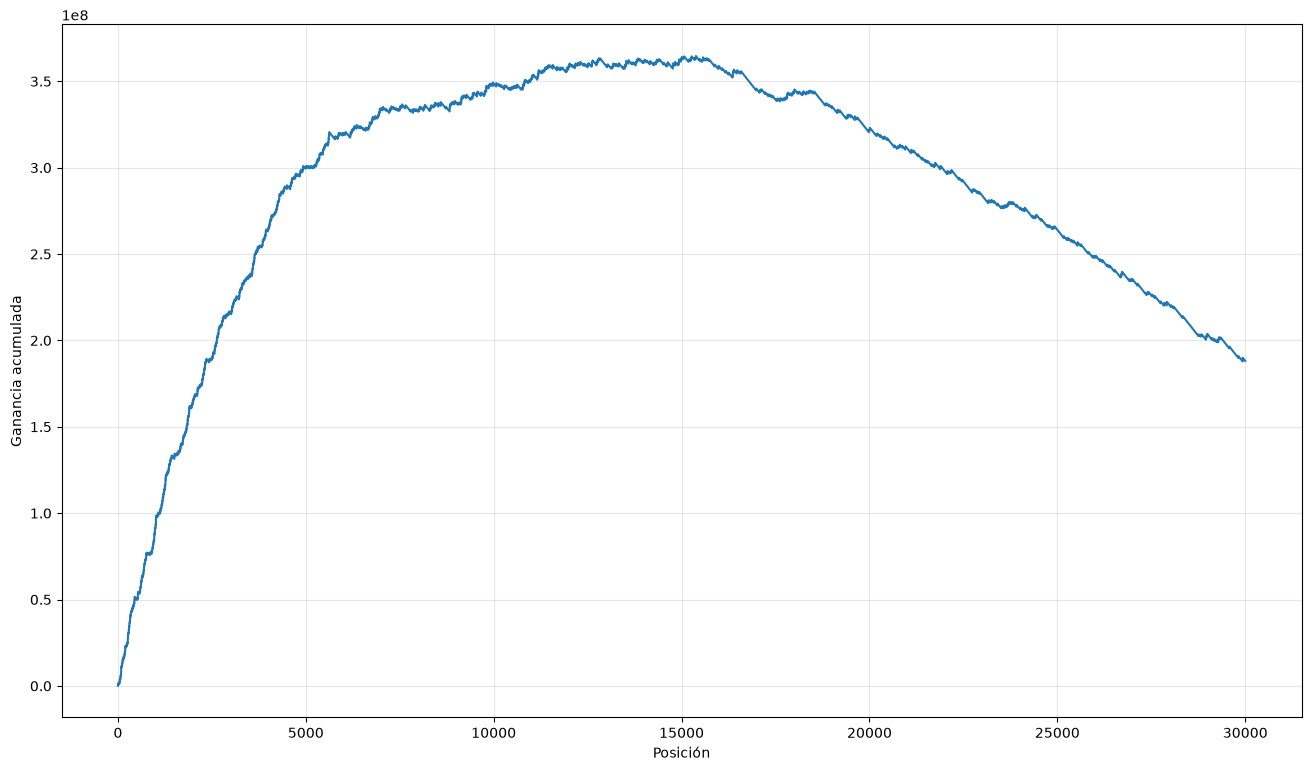

In [27]:
tb_prediccion = tb_prediccion.sort_values("prob", ascending=False).reset_index(drop=True)
tb_prediccion["gan"] = np.where(
    tb_prediccion["ternaria"].eq("baja+2"),
    1_072_500,
    -27_500,
)
tb_prediccion["ganancia_acumulada"] = tb_prediccion["gan"].cumsum()
tb_prediccion["pos"] = np.arange(1, len(tb_prediccion) + 1)

amostrar = 30_000
datos_plot = tb_prediccion.loc[tb_prediccion["pos"] <= amostrar]

plt.figure(figsize=(16, 9))
plt.plot(datos_plot["pos"], datos_plot["ganancia_acumulada"])
plt.xlabel("Posición")
plt.ylabel("Ganancia acumulada")
plt.grid(alpha=0.3)
plt.show()

## Ganancia bajo distintos cortes

In [28]:
def realidad_inicializar(dfuture, semilla):
    realidad = dfuture[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
    indices_public, indices_private = train_test_split(
        np.arange(len(realidad)),
        test_size=0.7,
        stratify=realidad["ternaria"],
        random_state=semilla,
    )
    realidad["fold"] = np.int8(2)
    realidad.loc[indices_public, "fold"] = np.int8(1)
    return realidad


def realidad_evaluar(realidad, predicciones):
    evaluacion = realidad.merge(
        predicciones[["numero_de_cliente", "foto_mes", "Predicted"]],
        on=["numero_de_cliente", "foto_mes"],
        how="left",
        validate="one_to_one",
    )
    seleccionados = evaluacion["Predicted"].eq(1)
    evaluacion["gan"] = 0
    evaluacion.loc[seleccionados, "gan"] = np.where(
        evaluacion.loc[seleccionados, "ternaria"].eq("baja+2"),
        1072500,
        -27500,
    )

    return {
        "public": evaluacion.loc[evaluacion["fold"].eq(1), "gan"].sum() / 0.3,
        "private": evaluacion.loc[evaluacion["fold"].eq(2), "gan"].sum() / 0.7,
        "total": evaluacion["gan"].sum(),
    }

In [29]:
drealidad = realidad_inicializar(
    dfuture_cpu,
    PARAM["semilla_kaggle"],
)

resultados_cortes = []
for envios in PARAM["cortes"]:
    predicciones_corte = tb_prediccion.copy()
    predicciones_corte["Predicted"] = np.int8(0)
    predicciones_corte.loc[: envios - 1, "Predicted"] = np.int8(1)

    resultado = realidad_evaluar(drealidad, predicciones_corte)
    resultados_cortes.append({"envios": envios, **resultado})
    print(
        f"Envios={envios}\t TOTAL={resultado['total']:.0f}"
        f"  Public={resultado['public']:.0f}"
        f" Private={resultado['private']:.0f}"
    )

resultados_cortes_df = pd.DataFrame(resultados_cortes)
resultados_cortes_df

Envios=4000	 TOTAL=265100000  Public=255750000 Private=269107143
Envios=4500	 TOTAL=288750000  Public=282058333 Private=291617857
Envios=5000	 TOTAL=300300000  Public=294341667 Private=302853571
Envios=5500	 TOTAL=311850000  Public=311575000 Private=311967857
Envios=6000	 TOTAL=320100000  Public=323216667 Private=318764286
Envios=6500	 TOTAL=322850000  Public=324133333 Private=322300000
Envios=7000	 TOTAL=334400000  Public=339075000 Private=332396429
Envios=7500	 TOTAL=333850000  Public=342558333 Private=330117857
Envios=8000	 TOTAL=333300000  Public=343841667 Private=328782143
Envios=8500	 TOTAL=336050000  Public=351908333 Private=329253571
Envios=9000	 TOTAL=337700000  Public=354658333 Private=330432143
Envios=9500	 TOTAL=342650000  Public=357591667 Private=336246429
Envios=10000	 TOTAL=348700000  Public=362816667 Private=342650000
Envios=10500	 TOTAL=345950000  Public=360525000 Private=339703571
Envios=11000	 TOTAL=350900000  Public=380050000 Private=338407143
Envios=11500	 TOTAL=35

,envios,public,private,total
0,4000,2.557500e+08,2.691071e+08,265100000
1,4500,2.820583e+08,2.916179e+08,288750000
2,5000,2.943417e+08,3.028536e+08,300300000
3,5500,3.115750e+08,3.119679e+08,311850000
4,6000,3.232167e+08,3.187643e+08,320100000
5,6500,3.241333e+08,3.223000e+08,322850000
6,7000,3.390750e+08,3.323964e+08,334400000
7,7500,3.425583e+08,3.301179e+08,333850000
8,8000,3.438417e+08,3.287821e+08,333300000
9,8500,3.519083e+08,3.292536e+08,336050000


In [30]:
with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)